# Reproduction of Duy et al. (2017): DNN for Intrusion Detection on NSL-KDD

This notebook adapts the original NSL-KDD notebook to reproduce the DNN configuration reported in the survey:

- **Dataset:** NSL-KDD
- **Task:** Binary intrusion detection: `normal` vs `attack`
- **Input:** All 41 original features
- **Categorical preprocessing:** One-hot encoding of `protocol_type`, `service`, and `flag`
- **DNN:** Four hidden layers, each with 60 ReLU neurons
- **Output:** Two-neuron Softmax layer
- **Optimizer:** Adam with learning rate `0.001`
- **Main metric:** F1-score

## Important reproducibility note

The survey reports that the 41 features were mapped to **120 input features**. Depending on the exact NSL-KDD file version and the categories present, modern one-hot encoding may produce a slightly different number, such as 121 or 122. The notebook prints the resulting input dimension rather than deleting valid categories merely to force 120 columns.

The notebook uses the official split:

- `KDDTrain+.txt` for training
- `KDDTest+.txt` for final testing

This is more faithful than randomly splitting only the training file.

## 1. Imports and reproducibility

In [ ]:
# Uncomment only when a package is missing in your environment.
# !pip install -q tensorflow scikit-learn pandas numpy matplotlib

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the official NSL-KDD train and test files

Place these files in the same folder as the notebook, or change `DATA_DIR`:

- `KDDTrain+.txt`
- `KDDTest+.txt`

On Kaggle, set `DATA_DIR` to the folder containing the dataset.

In [ ]:
# Change this path when necessary.
DATA_DIR = Path(".")

TRAIN_PATH = DATA_DIR / "KDDTrain+.txt"
TEST_PATH = DATA_DIR / "KDDTest+.txt"

if not TRAIN_PATH.exists() or not TEST_PATH.exists():
    raise FileNotFoundError(
        "Could not find KDDTrain+.txt and KDDTest+.txt. "
        "Upload both files or update DATA_DIR."
    )

COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

train_df = pd.read_csv(TRAIN_PATH, names=COLUMN_NAMES, header=None)
test_df = pd.read_csv(TEST_PATH, names=COLUMN_NAMES, header=None)

print("Training shape:", train_df.shape)
print("Testing shape: ", test_df.shape)
train_df.head()

Training shape: (125973, 43)
Testing shape:  (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 3. Basic data checks

In [ ]:
print("Missing values in training set:", int(train_df.isna().sum().sum()))
print("Missing values in testing set: ", int(test_df.isna().sum().sum()))
print("Duplicate training rows:", int(train_df.duplicated().sum()))
print("Duplicate testing rows: ", int(test_df.duplicated().sum()))

print("\nTraining labels:")
display(train_df["label"].value_counts().head(15))

print("\nCategorical cardinalities in training data:")
for column in ["protocol_type", "service", "flag"]:
    print(f"{column}: {train_df[column].nunique()} categories")

Missing values in training set: 0
Missing values in testing set:  0
Duplicate training rows: 0
Duplicate testing rows:  0

Training labels:


,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892



Categorical cardinalities in training data:
protocol_type: 3 categories
service: 70 categories
flag: 11 categories


## 4. Create the binary target

Every label other than `normal` is treated as an attack:

- `normal` → 0
- any attack type → 1

The trailing period is removed when present, so both `normal` and `normal.` are handled.

In [ ]:
def make_binary_target(labels: pd.Series) -> pd.Series:
    cleaned = labels.astype(str).str.strip().str.rstrip(".")
    return (cleaned != "normal").astype("int32")

y_train = make_binary_target(train_df["label"])
y_test = make_binary_target(test_df["label"])

# Keep all 41 predictive features. Remove only the target and difficulty columns.
X_train_raw = train_df.drop(columns=["label", "difficulty"])
X_test_raw = test_df.drop(columns=["label", "difficulty"])

print("Number of original predictive features:", X_train_raw.shape[1])
print("\nTraining target distribution:")
display(y_train.value_counts().rename(index={0: "normal", 1: "attack"}))

print("\nTesting target distribution:")
display(y_test.value_counts().rename(index={0: "normal", 1: "attack"}))

Number of original predictive features: 41

Training target distribution:


,count
label,
normal,67343
attack,58630



Testing target distribution:


,count
label,
attack,12833
normal,9711


## 5. Preprocess all 41 features correctly

The original notebook used `LabelEncoder` on categorical input columns. That creates artificial numerical ordering, for example making one service appear “larger” than another.

This version instead:

1. one-hot encodes `protocol_type`, `service`, and `flag`;
2. standardizes numerical features;
3. fits preprocessing **only on the training set**;
4. applies the same transformation to the official test set;
5. ignores previously unseen test categories safely.

In [ ]:
CATEGORICAL_COLUMNS = ["protocol_type", "service", "flag"]
NUMERICAL_COLUMNS = [
    column for column in X_train_raw.columns
    if column not in CATEGORICAL_COLUMNS
]

# Compatibility with both newer and older scikit-learn versions.
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        dtype=np.float32,
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
        dtype=np.float32,
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), NUMERICAL_COLUMNS),
        ("categorical", one_hot_encoder, CATEGORICAL_COLUMNS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
X_test = preprocessor.transform(X_test_raw).astype("float32")

feature_names = preprocessor.get_feature_names_out()

print("Original feature count:", X_train_raw.shape[1])
print("Encoded input dimension:", X_train.shape[1])
print("Training matrix shape:", X_train.shape)
print("Testing matrix shape: ", X_test.shape)

assert X_train.shape[1] == X_test.shape[1]
assert np.isfinite(X_train).all()
assert np.isfinite(X_test).all()

Original feature count: 41
Encoded input dimension: 122
Training matrix shape: (125973, 122)
Testing matrix shape:  (22544, 122)


### Inspect the generated features

The exact encoded dimension may differ slightly from the survey's reported 120 because categorical levels can vary by dataset release.

In [ ]:
display(pd.DataFrame({"encoded_feature": feature_names}).head(30))

,encoded_feature
0,duration
1,src_bytes
2,dst_bytes
3,land
4,wrong_fragment
5,urgent
6,hot
7,num_failed_logins
8,logged_in
9,num_compromised


## 6. Validation split

The official test set is kept untouched until final evaluation. A validation subset is taken only from the official training set by Keras during training.

`validation_split=0.20` uses the last 20% of the supplied training array. To make this reproducible while preserving class balance, we first create a stratified validation split explicitly.

In [ ]:
from sklearn.model_selection import train_test_split

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train.to_numpy(),
    test_size=0.20,
    random_state=SEED,
    stratify=y_train,
)

print("Fit set:", X_fit.shape, y_fit.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Official test set:", X_test.shape, y_test.shape)

Fit set: (100778, 122) (100778,)
Validation set: (25195, 122) (25195,)
Official test set: (22544, 122) (22544,)


## 7. Duy-style DNN

Architecture reported in the survey:

```text
Encoded input
    ↓
Dense(60, ReLU)
    ↓
Dense(60, ReLU)
    ↓
Dense(60, ReLU)
    ↓
Dense(60, ReLU)
    ↓
Dense(2, Softmax)
```

The paper summary does not fully specify all training choices such as batch size and epoch count. Here they are documented as experimental settings rather than claimed as original parameters.

In [ ]:
def build_duy_dnn(input_dim: int) -> tf.keras.Model:
    model = Sequential(
        [
            Input(shape=(input_dim,), name="input"),
            Dense(60, activation="relu", name="hidden_1"),
            Dense(60, activation="relu", name="hidden_2"),
            Dense(60, activation="relu", name="hidden_3"),
            Dense(60, activation="relu", name="hidden_4"),
            Dense(2, activation="softmax", name="output"),
        ],
        name="duy_2017_dnn",
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

duy_model = build_duy_dnn(X_fit.shape[1])
duy_model.summary()

Model: "duy_2017_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 60)             │         7,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,482 (72.20 KB)

 Trainable params: 18,482 (72.20 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the reproduction model

Early stopping is used to avoid wasting epochs after validation performance stops improving. Because this is not confirmed as part of the original paper, the best practice is to report it clearly in your methodology.

To run a stricter architecture-only reproduction without early stopping, remove the callback and use a fixed epoch count.

In [ ]:
EPOCHS = 50
BATCH_SIZE = 128

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1,
)

history = duy_model.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9844 - loss: 0.0523 - val_accuracy: 0.9901 - val_loss: 0.0246
Epoch 2/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9930 - loss: 0.0210 - val_accuracy: 0.9935 - val_loss: 0.0206
Epoch 3/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9942 - loss: 0.0170 - val_accuracy: 0.9936 - val_loss: 0.0199
Epoch 4/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9948 - loss: 0.0151 - val_accuracy: 0.9944 - val_loss: 0.0174
Epoch 5/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9953 - loss: 0.0133 - val_accuracy: 0.9942 - val_loss: 0.0178
Epoch 6/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9955 - loss: 0.0129 - val_accuracy: 0.9939 - val_loss: 0.0162
Epoch 7/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9961 - loss: 0.0112 - val_accuracy: 0.9944 - val_loss: 0.0170
Epoch 8/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9963 - loss: 0.0103 - val_accuracy: 0.

## 9. Training curves

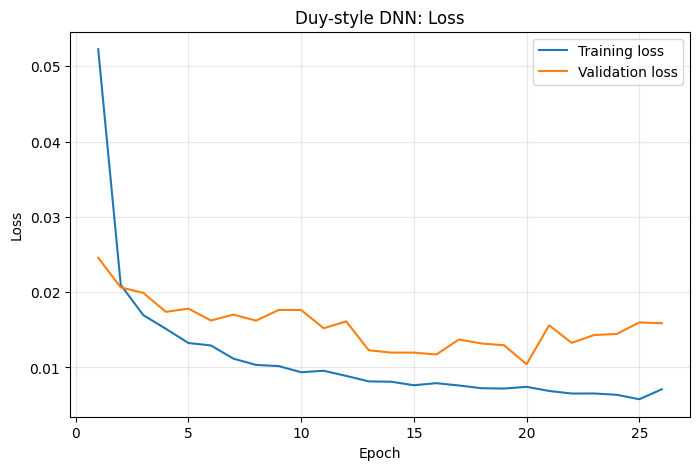

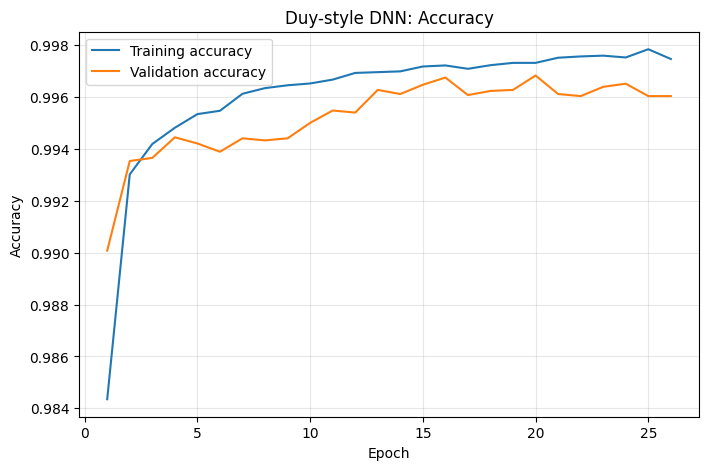

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

plt.figure(figsize=(8, 5))
plt.plot(history_df.index, history_df["loss"], label="Training loss")
plt.plot(history_df.index, history_df["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Duy-style DNN: Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df.index, history_df["accuracy"], label="Training accuracy")
plt.plot(history_df.index, history_df["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Duy-style DNN: Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Final evaluation on `KDDTest+`

AUC must be computed from the model's attack probability, not from hard class predictions.

model                    Duy-style DNN
accuracy                      0.791208
precision                     0.930038
recall_detection_rate         0.684719
f1                            0.788744
auc                           0.869668

Classification report:
              precision    recall  f1-score   support

      normal     0.6911    0.9319    0.7936      9711
      attack     0.9300    0.6847    0.7887     12833

    accuracy                         0.7912     22544
   macro avg     0.8105    0.8083    0.7912     22544
weighted avg     0.8271    0.7912    0.7908     22544



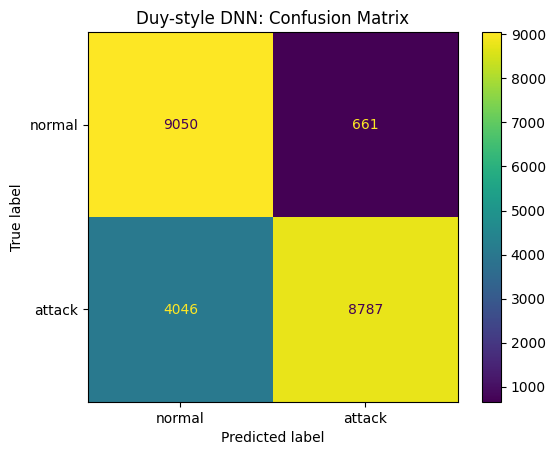

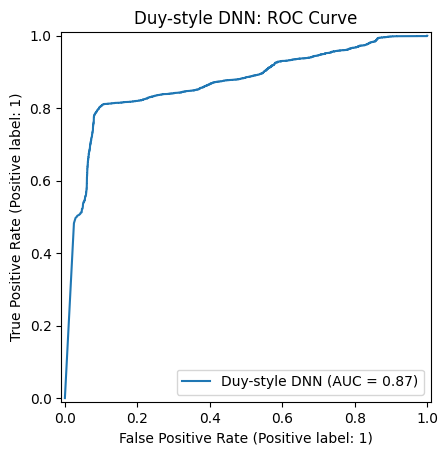

In [ ]:
def evaluate_binary_classifier(
    model: tf.keras.Model,
    X: np.ndarray,
    y_true: np.ndarray | pd.Series,
    model_name: str,
) -> dict:
    y_true_array = np.asarray(y_true)
    probabilities = model.predict(X, verbose=0)
    attack_probability = probabilities[:, 1]
    y_pred = np.argmax(probabilities, axis=1)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true_array, y_pred),
        "precision": precision_score(y_true_array, y_pred, zero_division=0),
        "recall_detection_rate": recall_score(
            y_true_array, y_pred, zero_division=0
        ),
        "f1": f1_score(y_true_array, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true_array, attack_probability),
    }

    print(pd.Series(results).to_string())
    print("\nClassification report:")
    print(
        classification_report(
            y_true_array,
            y_pred,
            target_names=["normal", "attack"],
            digits=4,
            zero_division=0,
        )
    )

    cm = confusion_matrix(y_true_array, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["normal", "attack"],
    ).plot(values_format="d")
    plt.title(f"{model_name}: Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_predictions(
        y_true_array,
        attack_probability,
        name=model_name,
    )
    plt.title(f"{model_name}: ROC Curve")
    plt.show()

    return results

duy_results = evaluate_binary_classifier(
    duy_model,
    X_test,
    y_test,
    "Duy-style DNN",
)

## 11. Compare your result with the survey

The survey reports:

\[
F1 = 96.2\%
\]

A different result does not automatically mean the implementation is wrong. Possible reasons include:

- incomplete training details in the survey;
- a different NSL-KDD file version;
- a different binary or multiclass target definition;
- a different random seed;
- different scaling or categorical handling;
- different epoch count or batch size;
- feature-ranking steps used by the original authors.

Record both your obtained result and the reported result transparently.

In [ ]:
reported_f1 = 0.962
obtained_f1 = duy_results["f1"]

comparison = pd.DataFrame(
    {
        "experiment": ["Duy et al. reported", "Our reproduction"],
        "f1": [reported_f1, obtained_f1],
    }
)
comparison["difference_from_reported"] = comparison["f1"] - reported_f1
display(comparison.style.format({"f1": "{:.4f}", "difference_from_reported": "{:+.4f}"}))

,experiment,f1,difference_from_reported
0,Duy et al. reported,0.9620,+0.0000
1,Our reproduction,0.7887,-0.1733


## 12. Tune the Duy-style decision threshold on validation data

The default Softmax decision uses a threshold close to `0.50`. Because the original model has very high precision but lower attack recall, this section selects a threshold that maximizes **validation F1**. The official `KDDTest+` set is not used for threshold selection.

In [ ]:
from sklearn.metrics import precision_recall_curve

duy_val_prob = duy_model.predict(X_val, verbose=0)[:, 1]
p, r, t = precision_recall_curve(y_val, duy_val_prob)
f1_values = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)

best_i = int(np.argmax(f1_values))
duy_best_threshold = float(t[best_i])

print("Best validation threshold:", round(duy_best_threshold, 4))
print("Validation precision:", round(float(p[best_i]), 4))
print("Validation recall:", round(float(r[best_i]), 4))
print("Validation F1:", round(float(f1_values[best_i]), 4))

Best validation threshold: 0.5236
Validation precision: 0.9978
Validation recall: 0.9957
Validation F1: 0.9968


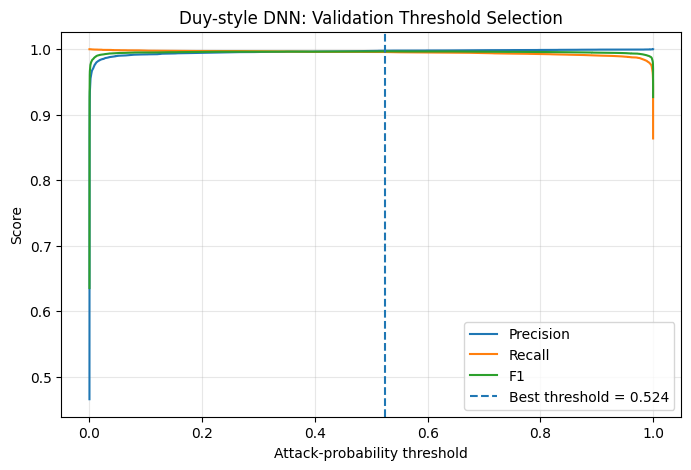

In [ ]:
threshold_df = pd.DataFrame({
    "threshold": t,
    "precision": p[:-1],
    "recall": r[:-1],
    "f1": f1_values,
})

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(duy_best_threshold, linestyle="--",
            label=f"Best threshold = {duy_best_threshold:.3f}")
plt.xlabel("Attack-probability threshold")
plt.ylabel("Score")
plt.title("Duy-style DNN: Validation Threshold Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13. Threshold-aware evaluation function

model                    Duy-style DNN (validation-tuned threshold)
threshold                                                  0.523596
accuracy                                                   0.790454
precision                                                  0.930277
recall_detection_rate                                      0.683083
f1                                                         0.787743
auc                                                        0.869668

              precision    recall  f1-score   support

      normal     0.6900    0.9323    0.7931      9711
      attack     0.9303    0.6831    0.7877     12833

    accuracy                         0.7905     22544
   macro avg     0.8102    0.8077    0.7904     22544
weighted avg     0.8268    0.7905    0.7900     22544



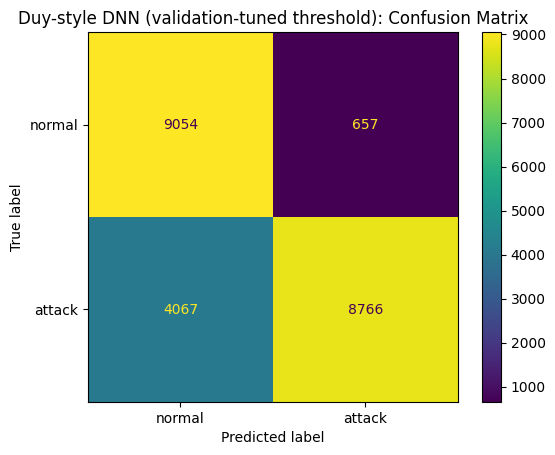

In [ ]:
def evaluate_with_threshold(model, X, y_true, threshold, model_name):
    y_true = np.asarray(y_true)
    attack_prob = model.predict(X, verbose=0)[:, 1]
    y_pred = (attack_prob >= threshold).astype("int32")

    results = {
        "model": model_name,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_detection_rate": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, attack_prob),
    }

    print(pd.Series(results).to_string())
    print()
    print(classification_report(
        y_true, y_pred,
        target_names=["normal", "attack"],
        digits=4,
        zero_division=0,
    ))

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_true, y_pred),
        display_labels=["normal", "attack"],
    ).plot(values_format="d")
    plt.title(f"{model_name}: Confusion Matrix")
    plt.show()

    return results

duy_tuned_results = evaluate_with_threshold(
    duy_model, X_test, y_test,
    duy_best_threshold,
    "Duy-style DNN (validation-tuned threshold)",
)

## 14. Alternative funnel DNN

This replaces the previous dropout/class-weight experiment. The new model tests an architectural change only:

```text
Encoded input → 128 → 64 → 32 → 16 → Softmax(2)
```

No dropout and no class weights are used because the original model did not show strong same-distribution overfitting and the training classes are not severely imbalanced.

In [ ]:
def build_funnel_dnn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,), name="input"),
        Dense(128, activation="relu", name="hidden_1"),
        Dense(64, activation="relu", name="hidden_2"),
        Dense(32, activation="relu", name="hidden_3"),
        Dense(16, activation="relu", name="hidden_4"),
        Dense(2, activation="softmax", name="output"),
    ], name="funnel_dnn")

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

funnel_model = build_funnel_dnn(X_fit.shape[1])
funnel_model.summary()

Model: "funnel_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,642 (104.07 KB)

 Trainable params: 26,642 (104.07 KB)

 Non-trainable params: 0 (0.00 B)

## 15. Train the funnel model

In [ ]:
funnel_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

funnel_history = funnel_model.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=128,
    callbacks=funnel_callbacks,
    verbose=1,
)

Epoch 1/60
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9847 - loss: 0.0487 - val_accuracy: 0.9913 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 2/60
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9928 - loss: 0.0204 - val_accuracy: 0.9932 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 3/60
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9941 - loss: 0.0169 - val_accuracy: 0.9936 - val_loss: 0.0199 - learning_rate: 0.0010
Epoch 4/60
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9949 - loss: 0.0147 - val_accuracy: 0.9933 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 5/60
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9952 - loss: 0.0137 - val_accuracy: 0.9937 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 6/60
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9957 - loss: 0.0127 - val_accuracy: 0.9945 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 7/60
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9958 - loss: 0.0124 - 

## 16. Funnel-model learning curves

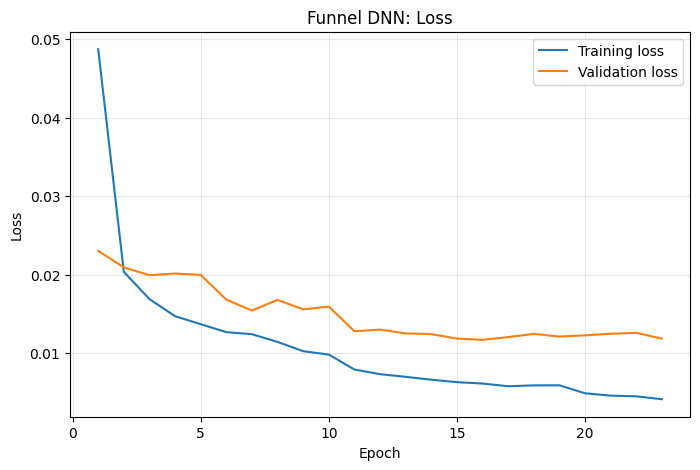

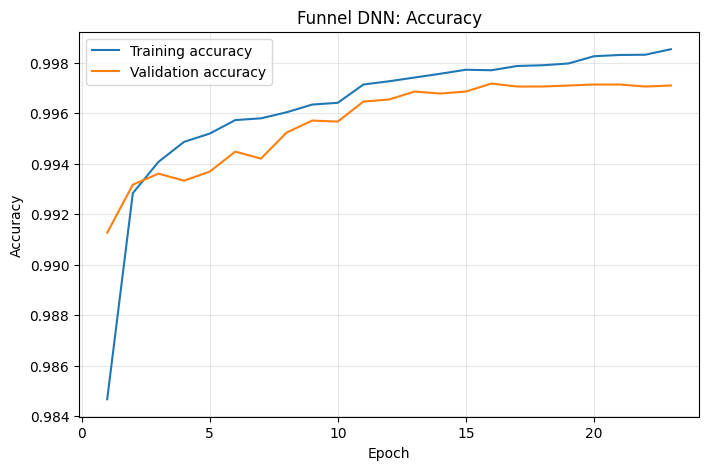

In [ ]:
funnel_history_df = pd.DataFrame(funnel_history.history)
funnel_history_df.index = np.arange(1, len(funnel_history_df) + 1)

plt.figure(figsize=(8, 5))
plt.plot(funnel_history_df.index, funnel_history_df["loss"], label="Training loss")
plt.plot(funnel_history_df.index, funnel_history_df["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Funnel DNN: Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(funnel_history_df.index, funnel_history_df["accuracy"], label="Training accuracy")
plt.plot(funnel_history_df.index, funnel_history_df["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Funnel DNN: Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 17. Select the funnel model's threshold using validation data

In [ ]:
funnel_val_prob = funnel_model.predict(X_val, verbose=0)[:, 1]
fp, fr, ft = precision_recall_curve(y_val, funnel_val_prob)
ff1 = 2 * fp[:-1] * fr[:-1] / (fp[:-1] + fr[:-1] + 1e-12)

funnel_best_i = int(np.argmax(ff1))
funnel_best_threshold = float(ft[funnel_best_i])

print("Best validation threshold:", round(funnel_best_threshold, 4))
print("Validation precision:", round(float(fp[funnel_best_i]), 4))
print("Validation recall:", round(float(fr[funnel_best_i]), 4))
print("Validation F1:", round(float(ff1[funnel_best_i]), 4))

Best validation threshold: 0.4579
Validation precision: 0.9978
Validation recall: 0.9962
Validation F1: 0.997


## 18. Final funnel evaluation on `KDDTest+`

model                    Funnel DNN (default threshold)
accuracy                                       0.770671
precision                                       0.97099
recall_detection_rate                          0.615522
f1                                             0.753434
auc                                            0.889642

Classification report:
              precision    recall  f1-score   support

      normal     0.6576    0.9757    0.7857      9711
      attack     0.9710    0.6155    0.7534     12833

    accuracy                         0.7707     22544
   macro avg     0.8143    0.7956    0.7695     22544
weighted avg     0.8360    0.7707    0.7673     22544



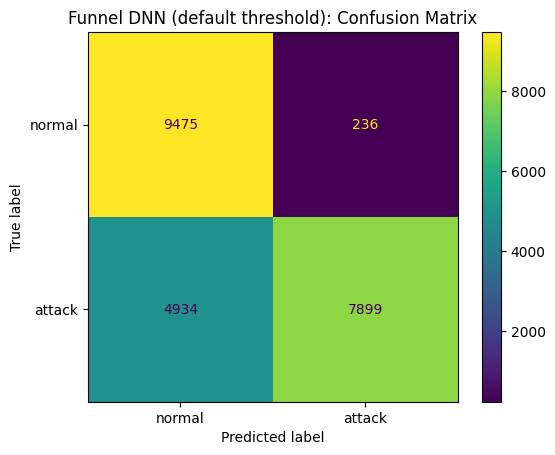

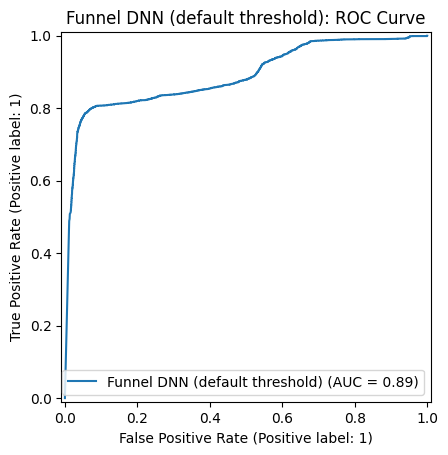

model                    Funnel DNN (validation-tuned threshold)
threshold                                               0.457941
accuracy                                                0.771913
precision                                               0.970858
recall_detection_rate                                    0.61786
f1                                                      0.755143
auc                                                     0.889642

              precision    recall  f1-score   support

      normal     0.6589    0.9755    0.7865      9711
      attack     0.9709    0.6179    0.7551     12833

    accuracy                         0.7719     22544
   macro avg     0.8149    0.7967    0.7708     22544
weighted avg     0.8365    0.7719    0.7687     22544



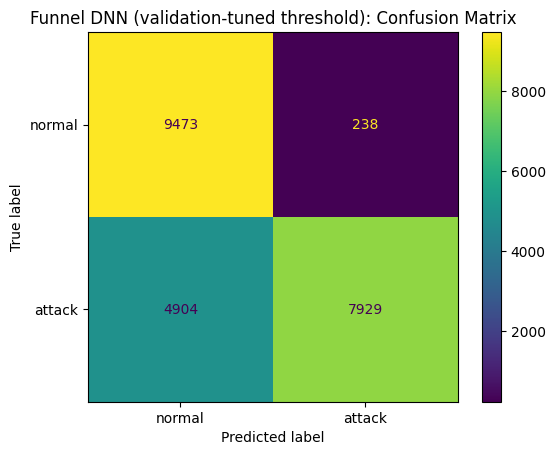

In [ ]:
funnel_default_results = evaluate_binary_classifier(
    funnel_model,
    X_test,
    y_test,
    "Funnel DNN (default threshold)",
)

funnel_tuned_results = evaluate_with_threshold(
    funnel_model,
    X_test,
    y_test,
    funnel_best_threshold,
    "Funnel DNN (validation-tuned threshold)",
)

## 19. Final comparison

In [ ]:
comparison_results = pd.DataFrame([
    {**duy_results, "threshold": 0.50},
    duy_tuned_results,
    {**funnel_default_results, "threshold": 0.50},
    funnel_tuned_results,
])

comparison_results = comparison_results[
    ["model", "threshold", "accuracy", "precision",
     "recall_detection_rate", "f1", "auc"]
].set_index("model")

display(comparison_results.style.format("{:.4f}"))

,threshold,accuracy,precision,recall_detection_rate,f1,auc
model,,,,,,
Duy-style DNN,0.5000,0.7912,0.9300,0.6847,0.7887,0.8697
Duy-style DNN (validation-tuned threshold),0.5236,0.7905,0.9303,0.6831,0.7877,0.8697
Funnel DNN (default threshold),0.5000,0.7707,0.9710,0.6155,0.7534,0.8896
Funnel DNN (validation-tuned threshold),0.4579,0.7719,0.9709,0.6179,0.7551,0.8896


## 20. Compare with Duy et al.'s reported F1

In [ ]:
reported_f1 = 0.962

reported_comparison = comparison_results[["f1"]].copy()
reported_comparison.loc["Duy et al. reported", "f1"] = reported_f1
reported_comparison["difference_from_reported"] = (
    reported_comparison["f1"] - reported_f1
)

display(
    reported_comparison.sort_values("f1", ascending=False).style.format({
        "f1": "{:.4f}",
        "difference_from_reported": "{:+.4f}",
    })
)

,f1,difference_from_reported
model,,
Duy et al. reported,0.9620,+0.0000
Duy-style DNN,0.7887,-0.1733
Duy-style DNN (validation-tuned threshold),0.7877,-0.1743
Funnel DNN (validation-tuned threshold),0.7551,-0.2069
Funnel DNN (default threshold),0.7534,-0.2086


## 21. Optional Logistic Regression baseline

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
baseline.fit(X_fit, y_fit)

baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

baseline_results = {
    "model": "Logistic Regression baseline",
    "threshold": 0.50,
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall_detection_rate": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
    "auc": roc_auc_score(y_test, baseline_prob),
}

all_results = pd.concat([
    comparison_results.reset_index(),
    pd.DataFrame([baseline_results]),
], ignore_index=True).set_index("model")

display(all_results.style.format("{:.4f}"))

,threshold,accuracy,precision,recall_detection_rate,f1,auc
model,,,,,,
Duy-style DNN,0.5000,0.7912,0.9300,0.6847,0.7887,0.8697
Duy-style DNN (validation-tuned threshold),0.5236,0.7905,0.9303,0.6831,0.7877,0.8697
Funnel DNN (default threshold),0.5000,0.7707,0.9710,0.6155,0.7534,0.8896
Funnel DNN (validation-tuned threshold),0.4579,0.7719,0.9709,0.6179,0.7551,0.8896
Logistic Regression baseline,0.5000,0.7542,0.9172,0.6246,0.7432,0.7960


## 22. Save models, preprocessing, and selected thresholds

In [ ]:
import json
import joblib

duy_model.save("duy_2017_dnn.keras")
funnel_model.save("funnel_dnn.keras")
joblib.dump(preprocessor, "nsl_kdd_preprocessor.joblib")

with open("decision_thresholds.json", "w", encoding="utf-8") as file:
    json.dump({
        "duy_style_threshold": float(duy_best_threshold),
        "funnel_threshold": float(funnel_best_threshold),
    }, file, indent=2)

print("Saved both models, the preprocessing pipeline, and thresholds.")

Saved both models, the preprocessing pipeline, and thresholds.


## 23. Report methodology

> We first reproduced the DNN architecture reported by Duy et al. using four hidden layers of 60 ReLU neurons. We then implemented a funnel-shaped DNN with hidden dimensions 128, 64, 32, and 16 to test whether progressive representation compression improved generalization. For both models, the classification threshold was selected by maximizing F1-score on a validation subset derived exclusively from KDDTrain+. Final evaluation was performed on the untouched KDDTest+ set using accuracy, precision, attack detection rate, F1-score, ROC-AUC, and confusion matrices.

The Duy-style network is the reproduction experiment. The funnel network is the architectural extension. Threshold-tuned and default-threshold results must be reported separately.